In [1]:
text = open('../input.txt').read()
chars = sorted(set(text))
vocab_size = len(chars) # 91
stoi = {c: i for i, c in enumerate(chars)} # map char to ID
itos = {i: c for i, c in enumerate(chars)} # ID to character mapping
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

In [2]:
import torch
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

In [3]:
block_size = 1 # context length
batch_size = 1024

def get_batch(split):
    d = train_data if split == 'train' else val_data
    # torch.randint(high,size)-> random ints in [0,high). size-> shape of output
    # a tensor of batch_size random integers, each in the range [0, len(d) - block_size).
    # gets the indexes for this batch
    ix = torch.randint(len(d)-block_size, (batch_size,))
    # for each batch, get the block_size next chars and concatenate
    x = torch.stack([d[i:i+block_size] for i in ix])
    # y is the next char in the sequence that the model will estimate
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x, y

In [4]:
import torch.nn as nn
from torch.nn import functional as F

class BigramLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # create V x V lookup table.
        self.token_emb = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_emb(idx)
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            # calculate the negative log probability the model assigns to the correct token
            # pass in the predictions and the answers
            loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))
        return logits, loss

In [5]:
blm = BigramLM(vocab_size)
optimizer = torch.optim.AdamW(blm.parameters(), lr=1e-3)
for step in range(10001):
    xb, yb = get_batch('train')
    logits, loss = blm(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 500 == 0:
        print(step, loss.item())

0 5.0741286277771
500 4.336259841918945
1000 3.8028743267059326
1500 3.437631845474243
2000 3.146021842956543
2500 2.91766357421875
3000 2.7277841567993164
3500 2.6384429931640625
4000 2.5940158367156982
4500 2.5075390338897705
5000 2.5023913383483887
5500 2.523861885070801
6000 2.4444761276245117
6500 2.509172201156616
7000 2.4528303146362305
7500 2.433357000350952
8000 2.440054416656494
8500 2.467648983001709
9000 2.464421510696411
9500 2.4222967624664307
10000 2.4231338500976562


In [6]:
@torch.no_grad()
def generate(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        logits, _ = model(idx)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    return idx
# To make more efficient, use a kv cache so we do not recompute all the logits over all positions and only keep the last one

start = torch.zeros((1, 1), dtype=torch.long)  # seed with char 0
print(decode(generate(blm, start, 300)[0].tolist()))


Be; ilis t songagreerengito inglerekesthede e, nnvese g
y aplabeenctere adeampspo-----ithacor VIV.”
“I._ f all apare we iz. ild,  ng spligngr.
Hindde aizatir ofier we antftasasalffisir. iteaver then, the at aindin m lly chemof dilsier wil aprd and, dindis 1*9ERI e atingheres tshove withe, woo_massts


The model had converged around 5000 steps


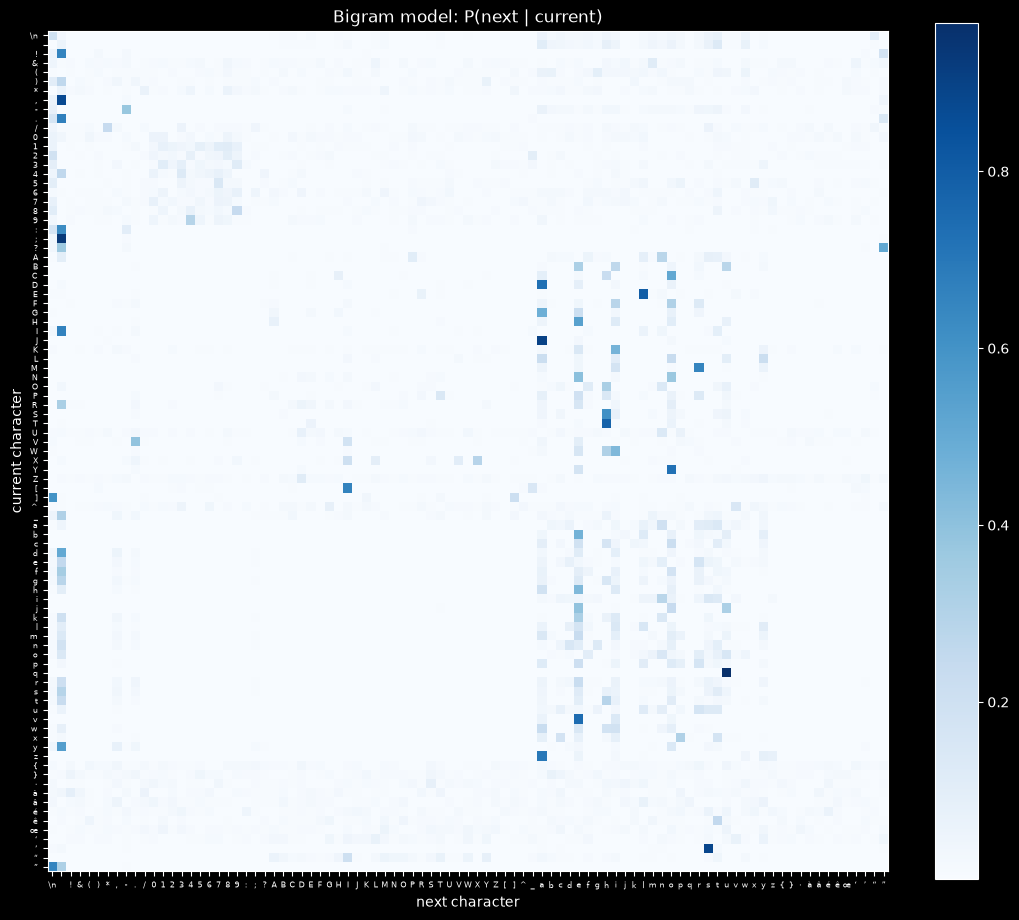

In [7]:
import matplotlib.pyplot as plt
import torch

# Pull the learned weights: shape (vocab_size, vocab_size)
W = blm.token_emb.weight.detach().cpu()

# Optional but recommended: convert logits -> probabilities per row
# so each row reads as "P(next char | current char)"
P = torch.softmax(W, dim=1)

fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(P, cmap='Blues')

# Label axes with actual characters
ticks = range(vocab_size)
labels = [repr(itos[i])[1:-1] for i in ticks]   # strip outer quotes from repr
ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=6)
ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)

ax.set_xlabel("next character")
ax.set_ylabel("current character")
ax.set_title("Bigram model: P(next | current)")
fig.colorbar(im, ax=ax, fraction=0.046)

We have rediscovered what the lookup table computed explicitly